In [17]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

In [18]:
df=pd.read_csv("dermatology.csv", sep="\t", na_values=["?"])

In [19]:
print(df.head())

   Erythema  Scathing  Definite Borders  Itching  Koebner   Polygonal  \
0         2         2                 0        3         0          0   
1         3         3                 3        2         1          0   
2         2         1                 2        3         1          3   
3         2         2                 2        0         0          0   
4         2         3                 2        2         2          2   

   Follicular  Oral  Knee  Scalp  ...  Disapperance  Vacuolisation  \
0           0     0     1      0  ...             0              0   
1           0     0     1      1  ...             0              0   
2           0     3     0      0  ...             0              2   
3           0     0     3      2  ...             3              0   
4           0     2     0      0  ...             2              3   

   Spongiosis  Retes  Follicular.1  Perifollicular  Inflamatory  Band-like  \
0           3      0             0               0            

In [20]:
df.dtypes

Erythema              int64
Scathing              int64
Definite Borders      int64
Itching               int64
Koebner               int64
Polygonal             int64
Follicular            int64
Oral                  int64
Knee                  int64
Scalp                 int64
Family Hostory        int64
Melanin               int64
Eosinophils           int64
PNL                   int64
Fibrosis              int64
Exocytosis            int64
Acanothosis           int64
Hyperkeratosis        int64
Parakeratosis         int64
Clubbing              int64
Elongation            int64
Thinning              int64
Spongiform            int64
Munro                 int64
Focal                 int64
Disapperance          int64
Vacuolisation         int64
Spongiosis            int64
Retes                 int64
Follicular.1          int64
Perifollicular        int64
Inflamatory           int64
Band-like             int64
Age                 float64
Disease               int64
dtype: object

In [21]:
df.isna().sum()

Erythema            0
Scathing            0
Definite Borders    0
Itching             0
Koebner             0
Polygonal           0
Follicular          0
Oral                0
Knee                0
Scalp               0
Family Hostory      0
Melanin             0
Eosinophils         0
PNL                 0
Fibrosis            0
Exocytosis          0
Acanothosis         0
Hyperkeratosis      0
Parakeratosis       0
Clubbing            0
Elongation          0
Thinning            0
Spongiform          0
Munro               0
Focal               0
Disapperance        0
Vacuolisation       0
Spongiosis          0
Retes               0
Follicular.1        0
Perifollicular      0
Inflamatory         0
Band-like           0
Age                 8
Disease             0
dtype: int64

In [22]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

In [23]:
df.isna().sum()

Erythema            0
Scathing            0
Definite Borders    0
Itching             0
Koebner             0
Polygonal           0
Follicular          0
Oral                0
Knee                0
Scalp               0
Family Hostory      0
Melanin             0
Eosinophils         0
PNL                 0
Fibrosis            0
Exocytosis          0
Acanothosis         0
Hyperkeratosis      0
Parakeratosis       0
Clubbing            0
Elongation          0
Thinning            0
Spongiform          0
Munro               0
Focal               0
Disapperance        0
Vacuolisation       0
Spongiosis          0
Retes               0
Follicular.1        0
Perifollicular      0
Inflamatory         0
Band-like           0
Age                 0
Disease             0
dtype: int64

In [30]:
df.columns

Index(['Erythema', 'Scathing', 'Definite Borders', 'Itching', 'Koebner ',
       'Polygonal', 'Follicular', 'Oral', 'Knee', 'Scalp', 'Family Hostory',
       'Melanin', 'Eosinophils', 'PNL', 'Fibrosis', 'Exocytosis',
       'Acanothosis', 'Hyperkeratosis', 'Parakeratosis', 'Clubbing',
       'Elongation', 'Thinning', 'Spongiform', 'Munro', 'Focal',
       'Disapperance', 'Vacuolisation', 'Spongiosis', 'Retes', 'Follicular.1',
       'Perifollicular', 'Inflamatory', 'Band-like', 'Age', 'Disease'],
      dtype='object')

In [32]:
X=df.drop('Disease', axis=1)
Y=df['Disease']

In [33]:
print(X.shape)

(366, 34)


In [35]:
print(Y.value_counts())

Disease
1    112
3     72
2     61
5     52
4     49
6     20
Name: count, dtype: int64


### Train_Test_Split

In [37]:
X_train, X_test, Y_train,Y_test=train_test_split(X, Y, test_size=0.2 , random_state=42)

In [39]:
print("Training data:", X_train.shape)

Training data (292, 34)


In [41]:
print("Testing data:", X_test.shape)

Testing data: (74, 34)


## Scale the Features 

In [44]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
print("Scaling done!")
print("Mean of training data (should be ~0):", X_train_scaled.mean().round(2))

Scaling done!
Mean of training data (should be ~0): -0.0


## Gradient Descent Regression 

In [63]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [64]:
X_age_train = X_train_scaled_df[['Age']]
X_age_test = X_test_scaled_df[['Age']]

In [65]:
sgd_model = SGDRegressor(learning_rate='constant', eta0=0.01, max_iter=1000, random_state=42)
sgd_model.fit(X_age_train, Y_train)

,loss,'squared_error'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [66]:
y_pred_sgd = sgd_model.predict(X_age_test)

In [67]:
mse = mean_squared_error(Y_test, y_pred_sgd)
r2 = r2_score(Y_test, y_pred_sgd)

In [68]:
print(f"Intercept (theta0): {sgd_model.intercept_[0]:.4f}")
print(f"Slope (theta1): {sgd_model.coef_[0]:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

Intercept (theta0): 2.7367
Slope (theta1): -0.5387
Mean Squared Error: 2.8747
R2 Score: -0.1058


## Random Forest Classifier

In [71]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [72]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [74]:
accuracy = accuracy_score(Y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

Random Forest Accuracy: 98.65%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      0.88      0.93         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74



## KNN Classifier

In [77]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, Y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [80]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [82]:
accuracy = accuracy_score(Y_test, y_pred_knn)
print(f"kNN Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_knn))

kNN Accuracy: 98.65%

Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.97      0.98        31
           2       0.90      1.00      0.95         9
           3       1.00      1.00      1.00        13
           4       1.00      1.00      1.00         8
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         3

    accuracy                           0.99        74
   macro avg       0.98      0.99      0.99        74
weighted avg       0.99      0.99      0.99        74



## K-Means Clustering

### Elbow Method

In [84]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_scaled)
    inertia.append(km.inertia_)


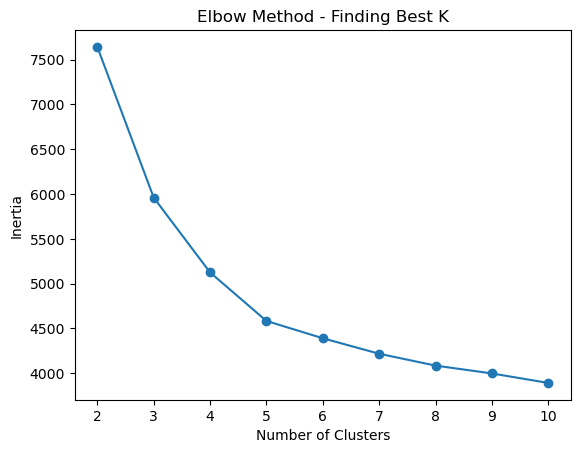

In [85]:
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method - Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

In [86]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

,n_clusters,6
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [88]:
y_pred_km = kmeans.predict(X_test_scaled)
ari = adjusted_rand_score(Y_test, y_pred_km)
nmi = normalized_mutual_info_score(Y_test, y_pred_km)

In [89]:
print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.6813
Normalized Mutual Info (NMI): 0.8672


## Agglomerative Hierarchical Clustering

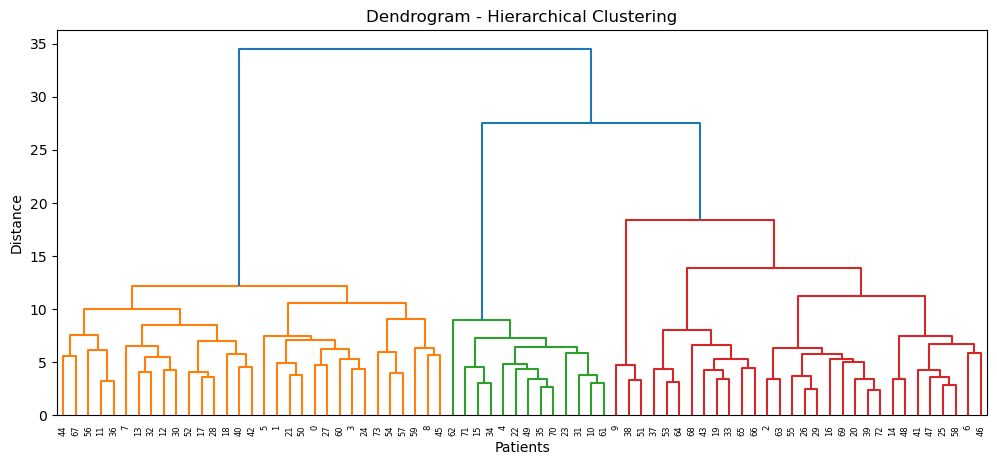

In [91]:
plt.figure(figsize=(12, 5))
dendrogram = sch.dendrogram(sch.linkage(X_test_scaled, method='ward'))
plt.title('Dendrogram - Hierarchical Clustering')
plt.xlabel('Patients')
plt.ylabel('Distance')
plt.show()

In [92]:
agg_model = AgglomerativeClustering(n_clusters=6, linkage='ward')
y_pred_agg = agg_model.fit_predict(X_test_scaled)

In [93]:
ari_agg = adjusted_rand_score(Y_test, y_pred_agg)
nmi_agg = normalized_mutual_info_score(Y_test, y_pred_agg)

print(f"Adjusted Rand Index (ARI): {ari_agg:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi_agg:.4f}")

Adjusted Rand Index (ARI): 0.6285
Normalized Mutual Info (NMI): 0.8327


In [1]:
models = ['Model 1\nGD Regression', 'Model 2\nRandom Forest', 'Model 3\nkNN', 
          'Model 4\nK-Means', 'Model 5\nAgglomerative']

In [3]:
scores = [0, 98.65, 98.65, 68.13, 62.85]
colors = ['red', 'green', 'green', 'orange', 'orange']

(0.0, 110.0)

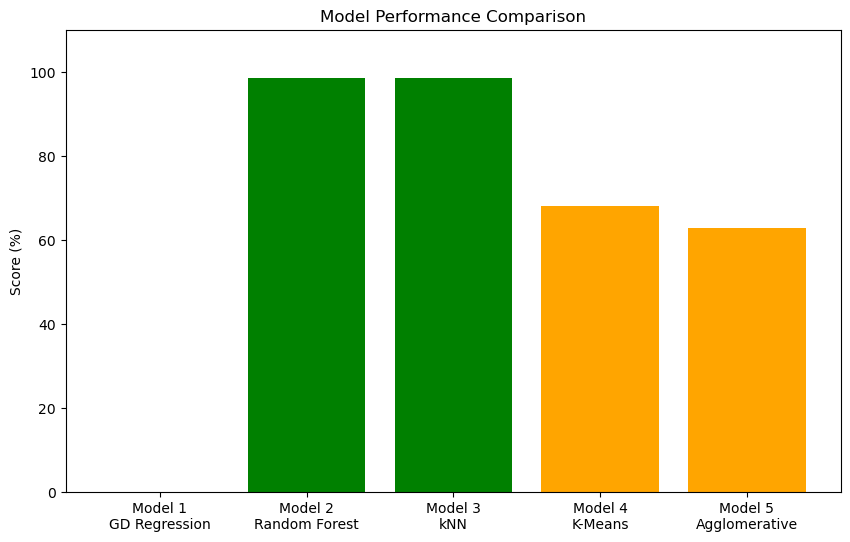

In [6]:
plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=colors)
plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.ylim(0, 110)

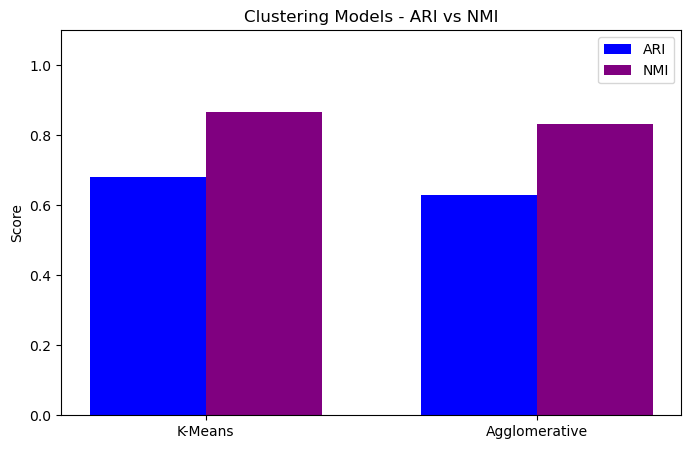

In [12]:
clustering_models = ['K-Means', 'Agglomerative']
ari_scores = [0.6813, 0.6285]
nmi_scores = [0.8672, 0.8327]

x = np.arange(len(clustering_models))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, ari_scores, width, label='ARI', color='blue')
plt.bar(x + width/2, nmi_scores, width, label='NMI', color='purple')
plt.title('Clustering Models - ARI vs NMI')
plt.xticks(x, clustering_models)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend()
plt.show()

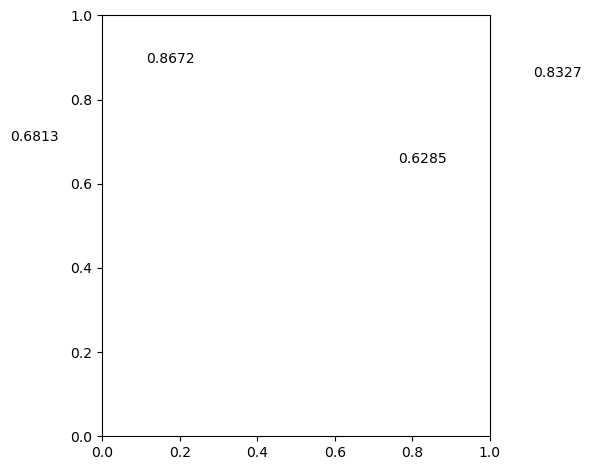

In [13]:
for i, (ari, nmi) in enumerate(zip(ari_scores, nmi_scores)):
    plt.text(i - width/2, ari + 0.02, f'{ari}', ha='center', fontsize=10)
    plt.text(i + width/2, nmi + 0.02, f'{nmi}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
print("="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
print(f"Model 1 - GD Regression     : R2 = -0.1058")
print(f"Model 2 - Random Forest     : Accuracy = 98.65% ")
print(f"Model 3 - kNN               : Accuracy = 98.65% ")
print(f"Model 4 - K-Means           : ARI=0.6813, NMI=0.8672 ")
print(f"Model 5 - Agglomerative     : ARI=0.6285, NMI=0.8327 ")
print("="*50)

FINAL MODEL SUMMARY
Model 1 - GD Regression     : R2 = -0.1058
Model 2 - Random Forest     : Accuracy = 98.65% 
Model 3 - kNN               : Accuracy = 98.65% 
Model 4 - K-Means           : ARI=0.6813, NMI=0.8672 
Model 5 - Agglomerative     : ARI=0.6285, NMI=0.8327 
